In [1]:
import time
import pandas as pd
from datetime import datetime, timedelta
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup #
import re

In [9]:
def get_kream_data_bs4(product_id):
    print("🚀 크롬 브라우저를 엽니다...")
    options = webdriver.ChromeOptions()
    options.add_argument("user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")
    options.add_experimental_option("detach", True)
    
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    
    url = f"https://kream.co.kr/products/{product_id}"
    driver.get(url)
    
    print("\n" + "🔥"*20)
    print("🚨 [1. 팝업 끄기 -> 2. 체결 거래 창 띄우기 -> 3. 스크롤 쫙 내리기]")
    print("다 하셨으면 터미널에서 엔터를 치세요!")
    print("🔥"*20 + "\n")
    
    input("👉 [준비 완료] 엔터(Enter)를 치세요! : ")
    
    print("\n엔터 확인! BeautifulSoup으로 HTML을 통째로 뜯어옵니다...")
    
    transactions = []
    try:
        # ✨ 핵심: Selenium이 열어둔 화면의 순수 HTML 코드를 그대로 가져옴
        html_source = driver.page_source
        
        # BeautifulSoup이 HTML 코드를 파이썬이 읽기 쉽게 요리해줌
        soup = BeautifulSoup(html_source, 'html.parser')
        
        # 캡처에서 확인한 전체 줄(body_list)을 싹 다 찾음
        rows = soup.find_all('div', class_='body_list')
        
        for row in rows:
            # 그 줄 안에서 3개의 칸(list_txt)을 찾음
            cols = row.find_all('div', class_='list_txt')
            
            # 사이즈, 가격, 날짜 3칸이 정상적으로 존재한다면
            if len(cols) >= 3:
                # .get_text(strip=True)는 화면에 보이든 말든 HTML에 있는 글자는 다 강제로 뽑아냄
                size = cols[0].get_text(strip=True)
                price_str = cols[1].get_text(strip=True)
                date_str = cols[2].get_text(strip=True)
                
                # "거래가" 같은 제목 텍스트는 빼고 진짜 "원"이 들어간 숫자 데이터만 추출
                if "원" in price_str:
                    transactions.append({
                        "date_str": date_str,
                        "size": size,
                        "price_str": price_str
                    })
                    
        print(f"✅ 화면에서 {len(transactions)}개의 찐 데이터를 찾아냈습니다!")

    except Exception as e:
        print(f"❌ 데이터 파싱 중 에러: {e}")
    
    # ==========================================
    # 4. 데이터프레임 변환 및 완벽 전처리
    # ==========================================
    df = pd.DataFrame(transactions)
    
    if not df.empty:
        # 1. 가격 정제: 한글, 특수문자, 띄어쓰기 싹 다 날리고 순수 숫자만 추출
        df['price_str'] = df['price_str'].astype(str).str.replace(r'[^0-9]', '', regex=True)
        df = df[df['price_str'] != ''] # 빈칸 방어
        df['price'] = df['price_str'].astype(int)
        
        today = datetime.now()
        
        # 2. 날짜 정제: '빠른배송', '⚡️' 등 불순물 제거
        def parse_kream_date(d_str):
            d_str = str(d_str)
            if "분 전" in d_str or "시간 전" in d_str:
                return today.date()
            elif "일 전" in d_str:
                # 숫자만 남기기 (예: "빠른배송 1일 전" -> "1")
                days_ago = int(re.sub(r'[^0-9]', '', d_str))
                return (today - timedelta(days=days_ago)).date()
            else:
                # 🌟 정규식 핵심: '숫자2개/숫자2개/숫자2개' 패턴만 쏙 뽑아냄
                match = re.search(r'\d{2}/\d{2}/\d{2}', d_str)
                if match:
                    clean_date = match.group() # "26/02/13" 추출 완료
                    return pd.to_datetime("20" + clean_date, format="%Y/%m/%d").date()
                else:
                    return None # 패턴이 아예 없으면 결측치 처리
                
        df['date'] = df['date_str'].apply(parse_kream_date)
        
        # 날짜 변환에 실패한 이상한 데이터(None)가 있다면 삭제
        df = df.dropna(subset=['date']) 
        df['date'] = pd.to_datetime(df['date'])
        
        # 3. 날짜순 정렬 및 청소
        df = df.sort_values('date').reset_index(drop=True)
        df = df.drop(columns=['price_str', 'date_str'])
        
    return df

In [10]:
df = get_kream_data_bs4("457531")
print("\n최종 결과:")
print(df.tail(10), "\n")
print(df.head(10))

🚀 크롬 브라우저를 엽니다...

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🚨 [1. 팝업 끄기 -> 2. 체결 거래 창 띄우기 -> 3. 스크롤 쫙 내리기]
다 하셨으면 터미널에서 엔터를 치세요!
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥



👉 [준비 완료] 엔터(Enter)를 치세요! :  



엔터 확인! BeautifulSoup으로 HTML을 통째로 뜯어옵니다...
✅ 화면에서 2700개의 찐 데이터를 찾아냈습니다!

최종 결과:
     size   price       date
2590  280  310000 2026-02-14
2591  275  305000 2026-02-14
2592  240  313000 2026-02-14
2593  265  295000 2026-02-14
2594  265  295000 2026-02-14
2595  250  320000 2026-02-14
2596  250  319000 2026-02-14
2597  280  309000 2026-02-14
2598  260  298000 2026-02-14
2599  275  313000 2026-02-14 

  size   price       date
0  260  290000 2026-01-12
1  270  279000 2026-01-12
2  250  292000 2026-01-12
3  275  295000 2026-01-12
4  265  280000 2026-01-12
5  275  297000 2026-01-12
6  260  290000 2026-01-12
7  285  317000 2026-01-12
8  275  299000 2026-01-12
9  280  317000 2026-01-12



🧠 머신러닝 파이프라인 재가동 (단위: 거래 건수/Tick)
👉 타겟 사이즈 자동 선정: 270 (가장 거래가 많음)
👉 전체 거래 건수: 535건 | 학습: 428건 | 테스트: 107건

📊 [AI 예측 성적표]
 - 평균 오차(MAE): 2,272 원
 - 설명력(R² Score): -0.4220


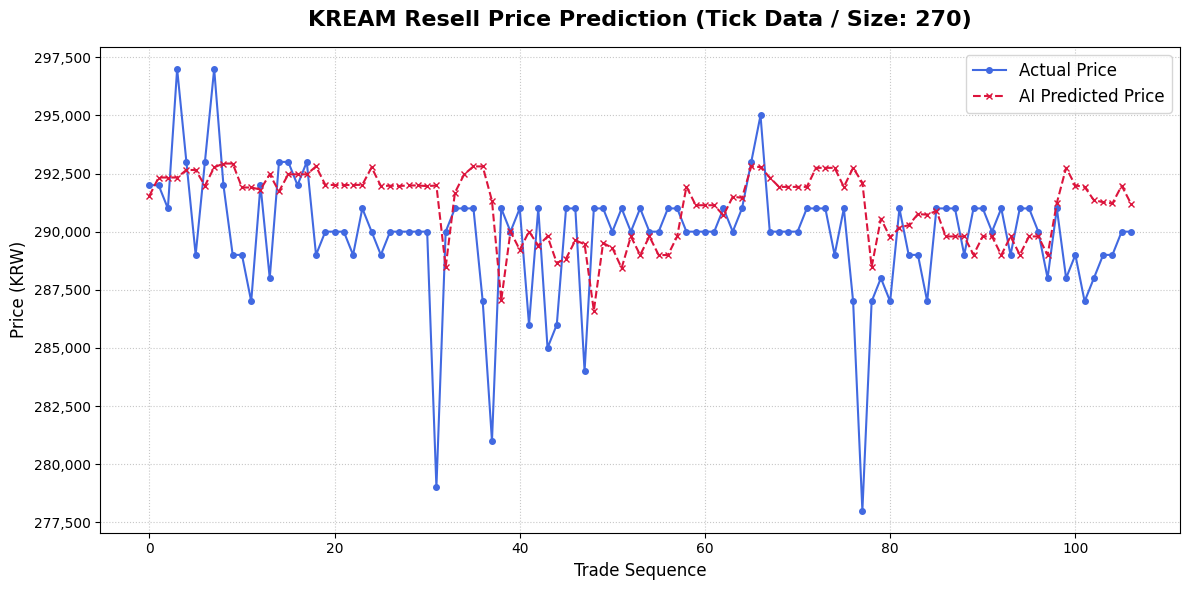

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("\n" + "="*40)
print("🧠 머신러닝 파이프라인 재가동 (단위: 거래 건수/Tick)")
print("="*40)

# ==========================================
# 1. 틱 데이터 전처리 (일별 묶기 생략)
# ==========================================
# 타겟 사이즈 필터링
top_size = df['size'].value_counts().idxmax()
print(f"👉 타겟 사이즈 자동 선정: {top_size} (가장 거래가 많음)")
df_target = df[df['size'] == top_size].copy()

# 🌟 핵심: groupby를 쓰지 않고 시간순으로 정렬만 해서 다 살립니다.
tick_df = df_target.sort_values('date').reset_index(drop=True)

# 래그 피처 & 이동평균 (날짜가 아니라 '이전 N번의 거래' 기준)
tick_df['price_lag_1'] = tick_df['price'].shift(1)  # 직전 거래가
tick_df['ma_5'] = tick_df['price'].rolling(window=5).mean()  # 최근 5번 거래의 평균가
tick_df['ma_20'] = tick_df['price'].rolling(window=20).mean() # 최근 20번 거래의 평균가
tick_df['std_20'] = tick_df['price'].rolling(window=20).std() # 최근 20번 거래의 가격 변동성

# 정답지(Target): '다음 번' 거래의 가격 예측
tick_df['target'] = tick_df['price'].shift(-1)

# 결측치 제거 (초기 20건의 거래만 희생됨)
ml_df = tick_df.dropna().reset_index(drop=True)

# ==========================================
# 2. 데이터 분할
# ==========================================
X = ml_df[['price', 'price_lag_1', 'ma_5', 'ma_20', 'std_20']]
y = ml_df['target']

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"👉 전체 거래 건수: {len(ml_df)}건 | 학습: {len(X_train)}건 | 테스트: {len(X_test)}건")

# ==========================================
# 3. 모델 학습
# ==========================================
model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

# ==========================================
# 4. 결과 시각화
# ==========================================
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n📊 [AI 예측 성적표]")
print(f" - 평균 오차(MAE): {mae:,.0f} 원")
print(f" - 설명력(R² Score): {r2:.4f}")

plt.figure(figsize=(12, 6))
# x축을 날짜 대신 '거래 순서(Index)'로 사용
plt.plot(range(len(y_test)), y_test.values, label='Actual Price', color='royalblue', marker='o', markersize=4)
plt.plot(range(len(preds)), preds, label='AI Predicted Price', color='crimson', linestyle='--', marker='x', markersize=5)

plt.title(f"KREAM Resell Price Prediction (Tick Data / Size: {top_size})", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Trade Sequence", fontsize=12)
plt.ylabel("Price (KRW)", fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()